# TP Final — Nuevas Features
## Distancia al CBD · Interacción night×violent · Beat Arrest Rate

**Materia:** Análisis de Datos — CEIA FIUBA (1B 2026)  
**Dataset:** Chicago Crimes 2025

Este notebook es autocontenido: replica el pipeline mínimo necesario (carga, merge, limpieza, split estratificado, imputación y feature engineering base) y luego implementa las tres nuevas features propuestas.

---

## 1. Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

RANDOM_STATE = 42
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 60)

## 2. Carga y enriquecimiento del dataset

Mismo flujo que en `1_tp_final_eda_fran.ipynb`: merge con la tabla de códigos IUCR y con Community Areas.

In [2]:
# Dataset principal de crímenes
df = pd.read_csv('Crimes_-_2025_20260312.csv')

# Tabla de Community Areas
community_areas = pd.read_csv(
    'Boundaries_-_Community_Areas_20260329.csv',
    usecols=['AREA_NUMBE', 'COMMUNITY']
).rename(columns={
    'AREA_NUMBE': 'Community Area',
    'COMMUNITY':  'Community Area Description'
})
community_areas['Community Area'] = community_areas['Community Area'].astype(int)

# Tabla de códigos IUCR
iucr_codes = pd.read_csv(
    'Chicago_Police_Department_-_Illinois_Uniform_Crime_Reporting_(IUCR)_Codes_20260329.csv'
).rename(columns={
    'PRIMARY DESCRIPTION':   'IUCR Primary',
    'SECONDARY DESCRIPTION': 'IUCR Secondary',
    'INDEX CODE':            'Index Code'
})
iucr_codes['IUCR'] = iucr_codes['IUCR'].str.zfill(4)

# Merge enriquecido
df_chicago = (
    df.merge(iucr_codes[['IUCR', 'IUCR Primary', 'IUCR Secondary', 'Index Code']],
             on='IUCR', how='left')
      .merge(community_areas, on='Community Area', how='left')
)

assert df.shape[0] == df_chicago.shape[0], 'El merge alteró la cantidad de filas'
print(f'Dataset enriquecido: {df_chicago.shape}')

Dataset enriquecido: (236686, 26)


## 3. Limpieza general

In [3]:
# Flag de coordenadas presentes (antes de imputar)
df_chicago['has_coords'] = df_chicago[['Latitude', 'Longitude']].notna().all(axis=1).astype(int)

# Columnas que no aportan al modelo
cols_drop = ['ID', 'Case Number', 'Year', 'Location', 'Updated On', 'Description', 'Block']
df_clean = df_chicago.drop(columns=cols_drop)

# Parseo de fechas
df_clean['Date'] = pd.to_datetime(df_clean['Date'], format='%m/%d/%Y %I:%M:%S %p', errors='coerce')

# Normalización de strings categóricos
cat_cols = ['Primary Type', 'Location Description', 'FBI Code', 'IUCR',
            'IUCR Primary', 'IUCR Secondary', 'Index Code', 'Community Area Description']
for col in cat_cols:
    if col in df_clean.columns:
        mask = df_clean[col].notna()
        df_clean.loc[mask, col] = df_clean.loc[mask, col].astype(str).str.strip().str.upper()

# Eliminar duplicados exactos
dups = df_clean.duplicated().sum()
if dups > 0:
    df_clean = df_clean.drop_duplicates().reset_index(drop=True)
    print(f'{dups} duplicados eliminados')

print(f'Forma tras limpieza: {df_clean.shape}')

525 duplicados eliminados
Forma tras limpieza: (236161, 20)


## 4. Split train / test estratificado

El split se realiza **antes** de cualquier imputación o transformación para evitar data leakage.
Se usa `stratify=y` porque `Arrest` está desbalanceado (~16 % positivos).

In [4]:
y = df_clean['Arrest'].astype(int)
X = df_clean.drop(columns=['Arrest'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')
print('\nProporción de clases en train:')
print(y_train.value_counts(normalize=True).round(4))
print('\nProporción de clases en test:')
print(y_test.value_counts(normalize=True).round(4))

X_train: (188928, 19) | X_test: (47233, 19)

Proporción de clases en train:
Arrest
0    0.8401
1    0.1599
Name: proportion, dtype: float64

Proporción de clases en test:
Arrest
0    0.8401
1    0.1599
Name: proportion, dtype: float64


## 5. Imputación de valores faltantes

Estrategia heredada del EDA (todos los faltantes son MAR con porcentaje bajo):

| Grupo | Estrategia |
|---|---|
| Coordenadas continuas | Mediana (no mueve el centroide geográfico) |
| Códigos geográficos enteros | Moda |
| Categóricos de texto | Constante `'UNKNOWN'` |

In [5]:
num_coords = ['Latitude', 'Longitude', 'X Coordinate', 'Y Coordinate']
num_codes  = ['Community Area', 'Ward', 'District', 'Beat']
cat_text   = ['Location Description', 'IUCR Primary', 'IUCR Secondary',
              'Index Code', 'Community Area Description']

imp_median = SimpleImputer(strategy='median')
imp_mode   = SimpleImputer(strategy='most_frequent')
imp_unk    = SimpleImputer(strategy='constant', fill_value='UNKNOWN')

# Fit en train, transform en ambos
X_train[num_coords] = imp_median.fit_transform(X_train[num_coords])
X_test[num_coords]  = imp_median.transform(X_test[num_coords])

X_train[num_codes]  = imp_mode.fit_transform(X_train[num_codes])
X_test[num_codes]   = imp_mode.transform(X_test[num_codes])

X_train[cat_text]   = imp_unk.fit_transform(X_train[cat_text])
X_test[cat_text]    = imp_unk.transform(X_test[cat_text])

assert X_train[num_coords + num_codes + cat_text].isna().sum().sum() == 0
print('Imputación OK — faltantes restantes:', X_train.isna().sum().sum())

Imputación OK — faltantes restantes: 0


## 6. Feature engineering base

Features temporales y de tipo de crimen necesarios como prerequisito para las nuevas features (en particular `is_night` e `is_violent`).

In [6]:
def build_time_features(df_):
    out = df_.copy()
    d = out['Date']
    out['hour']        = d.dt.hour
    out['day_of_week'] = d.dt.dayofweek
    out['month']       = d.dt.month
    out['quarter']     = d.dt.quarter
    out['day_of_year'] = d.dt.dayofyear
    out['is_weekend']  = (out['day_of_week'] >= 5).astype(int)
    out['is_night']    = ((out['hour'] >= 22) | (out['hour'] < 6)).astype(int)
    out['hour_sin']    = np.sin(2 * np.pi * out['hour'] / 24)
    out['hour_cos']    = np.cos(2 * np.pi * out['hour'] / 24)
    out['dow_sin']     = np.sin(2 * np.pi * out['day_of_week'] / 7)
    out['dow_cos']     = np.cos(2 * np.pi * out['day_of_week'] / 7)
    return out

X_train = build_time_features(X_train)
X_test  = build_time_features(X_test)

VIOLENT  = {'HOMICIDE', 'ASSAULT', 'BATTERY', 'ROBBERY', 'CRIM SEXUAL ASSAULT',
            'CRIMINAL SEXUAL ASSAULT', 'KIDNAPPING'}
PROPERTY = {'THEFT', 'BURGLARY', 'MOTOR VEHICLE THEFT', 'ARSON',
            'CRIMINAL DAMAGE', 'CRIMINAL TRESPASS'}

X_train['is_violent']  = X_train['Primary Type'].isin(VIOLENT).astype(int)
X_train['is_property'] = X_train['Primary Type'].isin(PROPERTY).astype(int)
X_test['is_violent']   = X_test['Primary Type'].isin(VIOLENT).astype(int)
X_test['is_property']  = X_test['Primary Type'].isin(PROPERTY).astype(int)

# beat_crime_rate (frecuencia de crímenes por Beat, aprendida en train)
beat_rate_map = X_train['Beat'].value_counts().to_dict()
fallback_rate = float(np.median(list(beat_rate_map.values())))
X_train['beat_crime_rate'] = X_train['Beat'].map(beat_rate_map).fillna(fallback_rate)
X_test['beat_crime_rate']  = X_test['Beat'].map(beat_rate_map).fillna(fallback_rate)

print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')
print('Features base creadas: hour, day_of_week, month, quarter, day_of_year,',
      'is_weekend, is_night, hour_sin, hour_cos, dow_sin, dow_cos,',
      'is_violent, is_property, beat_crime_rate')

X_train: (188928, 33) | X_test: (47233, 33)
Features base creadas: hour, day_of_week, month, quarter, day_of_year, is_weekend, is_night, hour_sin, hour_cos, dow_sin, dow_cos, is_violent, is_property, beat_crime_rate


---
# Nuevas Features
---

## 7. Distancia al CBD (Haversine)

distancia_cbd — train | min: 0.14 km | max: 28.70 km | media: 10.75 km
distancia_cbd — test  | min: 0.14 km | max: 28.69 km | media: 10.75 km


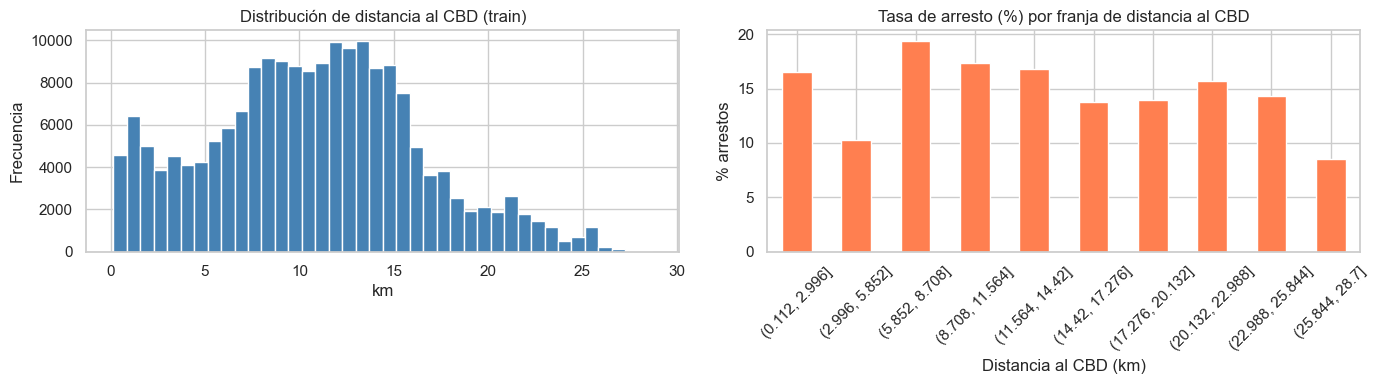

In [7]:
# ─────────────────────────────────────────────────────────────
# FEATURE: distancia_cbd
# Distancia de Haversine desde cada crimen al Loop de Chicago
# (lat 41.8827, lon -87.6227). Captura el gradiente urbano
# centro-periferia que correlaciona con tipo de crimen y arrestos.
# Se calcula sobre coordenadas ya imputadas (post §5).
# ─────────────────────────────────────────────────────────────

CBD_LAT, CBD_LON = 41.8827, -87.6227

def haversine_km(lat, lon, ref_lat=CBD_LAT, ref_lon=CBD_LON):
    """Distancia en km entre cada punto (lat, lon) y un punto de referencia."""
    R = 6371.0  # radio terrestre en km
    lat_r  = np.radians(lat)
    lon_r  = np.radians(lon)
    rlat_r = np.radians(ref_lat)
    rlon_r = np.radians(ref_lon)

    dlat = lat_r - rlat_r
    dlon = lon_r - rlon_r

    a = np.sin(dlat / 2) ** 2 + np.cos(rlat_r) * np.cos(lat_r) * np.sin(dlon / 2) ** 2
    return R * 2 * np.arcsin(np.sqrt(a))

X_train['distancia_cbd'] = haversine_km(X_train['Latitude'].values, X_train['Longitude'].values)
X_test['distancia_cbd']  = haversine_km(X_test['Latitude'].values,  X_test['Longitude'].values)

# Validación rápida
print(f"distancia_cbd — train | min: {X_train['distancia_cbd'].min():.2f} km | "
      f"max: {X_train['distancia_cbd'].max():.2f} km | "
      f"media: {X_train['distancia_cbd'].mean():.2f} km")
print(f"distancia_cbd — test  | min: {X_test['distancia_cbd'].min():.2f} km | "
      f"max: {X_test['distancia_cbd'].max():.2f} km | "
      f"media: {X_test['distancia_cbd'].mean():.2f} km")

# Distribución vs tasa de arresto (binned)
tmp = X_train[['distancia_cbd']].copy()
tmp['Arrest'] = y_train.values
tmp['dist_bin'] = pd.cut(tmp['distancia_cbd'], bins=10)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

tmp['distancia_cbd'].hist(bins=40, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Distribución de distancia al CBD (train)')
axes[0].set_xlabel('km')
axes[0].set_ylabel('Frecuencia')

arrest_rate = tmp.groupby('dist_bin', observed=True)['Arrest'].mean() * 100
arrest_rate.plot(kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Tasa de arresto (%) por franja de distancia al CBD')
axes[1].set_xlabel('Distancia al CBD (km)')
axes[1].set_ylabel('% arrestos')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 8. Interacción `is_night × is_violent`

                         n  tasa_arresto  pct_del_total
combo                                                  
Noche / Violento     16752         18.62            8.9
Día / No violento    95847         17.31           50.7
Día / Violento       40948         14.80           21.7
Noche / No violento  35381         12.53           18.7


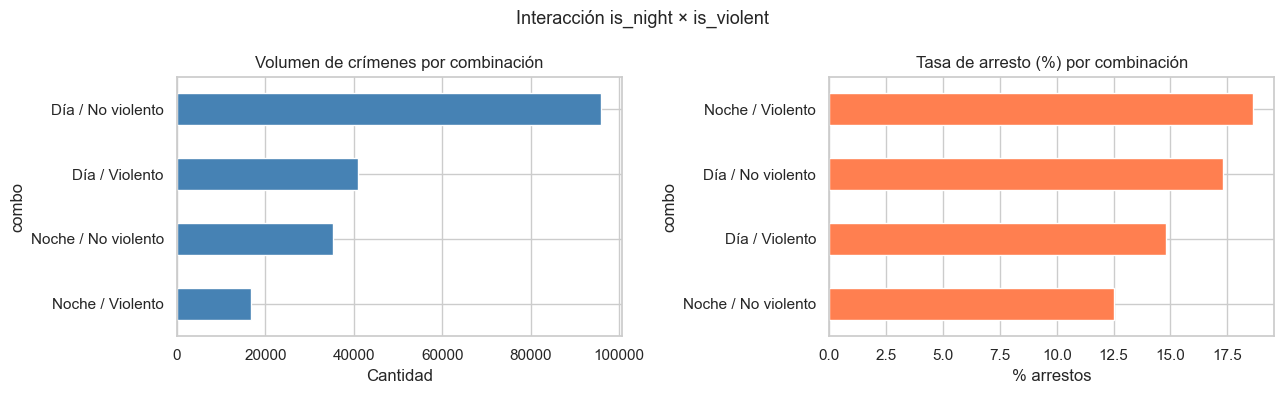

In [8]:
# ─────────────────────────────────────────────────────────────
# FEATURE: night_violent
# Interacción binaria is_night × is_violent.
# Un crimen violento nocturno tiene un perfil operativo distinto
# (menor visibilidad, menor presencia de testigos, respuesta
# policial diferente) que ninguna de las dos flags captura sola.
# ─────────────────────────────────────────────────────────────

X_train['night_violent'] = (X_train['is_night'] * X_train['is_violent']).astype(int)
X_test['night_violent']  = (X_test['is_night']  * X_test['is_violent']).astype(int)

# Distribución de las 4 combinaciones posibles
combos_train = (
    X_train[['is_night', 'is_violent', 'night_violent']]
    .assign(Arrest=y_train.values)
    .assign(combo=lambda d:
        d['is_night'].map({0: 'Día', 1: 'Noche'}) + ' / ' +
        d['is_violent'].map({0: 'No violento', 1: 'Violento'})
    )
)

conteo   = combos_train.groupby('combo').size().rename('n')
arr_rate = combos_train.groupby('combo')['Arrest'].mean().rename('tasa_arresto') * 100
resumen_combos = pd.concat([conteo, arr_rate], axis=1).sort_values('tasa_arresto', ascending=False)
resumen_combos['pct_del_total'] = (resumen_combos['n'] / resumen_combos['n'].sum() * 100).round(1)
print(resumen_combos.round(2))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

resumen_combos['n'].sort_values().plot(
    kind='barh', ax=axes[0], color='steelblue', edgecolor='white'
)
axes[0].set_title('Volumen de crímenes por combinación')
axes[0].set_xlabel('Cantidad')

resumen_combos['tasa_arresto'].sort_values().plot(
    kind='barh', ax=axes[1], color='coral', edgecolor='white'
)
axes[1].set_title('Tasa de arresto (%) por combinación')
axes[1].set_xlabel('% arrestos')

plt.suptitle('Interacción is_night × is_violent', fontsize=13)
plt.tight_layout()
plt.show()

## 9. `beat_arrest_rate`

beat_arrest_rate — train | min: 0.042 | max: 0.475 | media: 0.161 (tasa global: 0.160)
Beats en train: 274 | Beats no vistos en test: 0


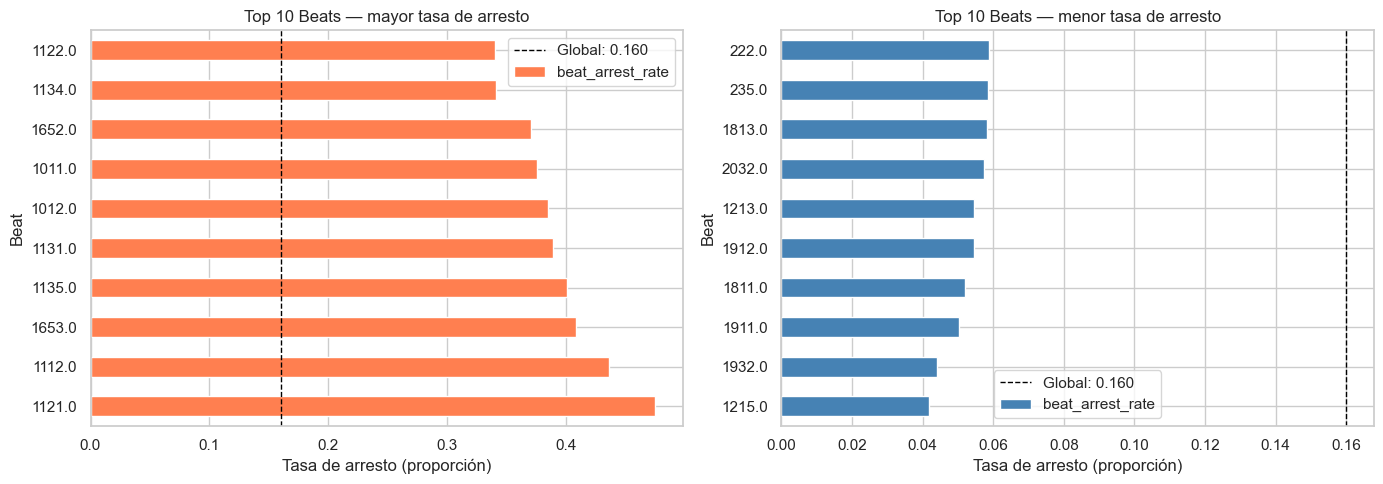

In [9]:
# ─────────────────────────────────────────────────────────────
# FEATURE: beat_arrest_rate
# Tasa histórica de arrestos por Beat, estimada SOLO con y_train
# (media de Arrest por Beat en el conjunto de entrenamiento).
# Es un prior geográfico del comportamiento policial: ciertos
# Beats tienen sistemáticamente más arrestos por su composición
# de delitos, dotación policial y recursos del área.
# Smoothing laplaciano (+1 arresto, +2 casos) para Beats con
# muy pocas observaciones, evitando tasas de 0% o 100% por
# muestras pequeñas.
# ─────────────────────────────────────────────────────────────

# Calcular tasa con smoothing sobre el TRAIN
beat_stats = (
    X_train[['Beat']]
    .assign(Arrest=y_train.values)
    .groupby('Beat')['Arrest']
    .agg(['sum', 'count'])
    .rename(columns={'sum': 'arrestos', 'count': 'total'})
)
beat_stats['beat_arrest_rate'] = (beat_stats['arrestos'] + 1) / (beat_stats['total'] + 2)
beat_arrest_map = beat_stats['beat_arrest_rate'].to_dict()

# Fallback: tasa global de train para Beats no vistos en test
global_rate = y_train.mean()

X_train['beat_arrest_rate'] = X_train['Beat'].map(beat_arrest_map).fillna(global_rate)
X_test['beat_arrest_rate']  = X_test['Beat'].map(beat_arrest_map).fillna(global_rate)

# Validación
print(f"beat_arrest_rate — train | min: {X_train['beat_arrest_rate'].min():.3f} | "
      f"max: {X_train['beat_arrest_rate'].max():.3f} | "
      f"media: {X_train['beat_arrest_rate'].mean():.3f} (tasa global: {global_rate:.3f})")
print(f"Beats en train: {beat_stats.shape[0]} | "
      f"Beats no vistos en test: {X_test['Beat'].map(beat_arrest_map).isna().sum()}")

# Top y bottom 10 Beats por tasa de arresto
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top10 = beat_stats['beat_arrest_rate'].sort_values(ascending=False).head(10)
bot10 = beat_stats['beat_arrest_rate'].sort_values().head(10)

top10.plot(kind='barh', ax=axes[0], color='coral',     edgecolor='white')
bot10.plot(kind='barh', ax=axes[1], color='steelblue', edgecolor='white')

axes[0].set_title('Top 10 Beats — mayor tasa de arresto')
axes[1].set_title('Top 10 Beats — menor tasa de arresto')
for ax in axes:
    ax.set_xlabel('Tasa de arresto (proporción)')
    ax.axvline(global_rate, color='black', linestyle='--', lw=1, label=f'Global: {global_rate:.3f}')
    ax.legend()

plt.tight_layout()
plt.show()

---
## 10. Resumen de features nuevas

In [10]:
nuevas = ['distancia_cbd', 'night_violent', 'beat_arrest_rate']

print('=== Estadísticas descriptivas (train) ===')
print(X_train[nuevas].describe().round(4))

print('\n=== Correlación con Arrest (train) ===')
for feat in nuevas:
    corr = X_train[feat].corr(y_train.astype(float))
    print(f'  {feat:<25} r = {corr:+.4f}')

print(f'\nX_train final: {X_train.shape} | X_test final: {X_test.shape}')

=== Estadísticas descriptivas (train) ===
       distancia_cbd  night_violent  beat_arrest_rate
count    188928.0000    188928.0000       188928.0000
mean         10.7527         0.0887            0.1609
std           5.5940         0.2843            0.0723
min           0.1401         0.0000            0.0418
25%           6.9255         0.0000            0.1191
50%          10.8169         0.0000            0.1513
75%          14.3858         0.0000            0.1829
max          28.6996         1.0000            0.4746

=== Correlación con Arrest (train) ===
  distancia_cbd             r = -0.0083
  night_violent             r = +0.0225
  beat_arrest_rate          r = +0.1979

X_train final: (188928, 36) | X_test final: (47233, 36)


### Feature: `hour_arrest_rate`

Tasa histórica de arrestos para la **hora del día** en que ocurrió el crimen,
estimada sobre el conjunto de entrenamiento con smoothing laplaciano.

A diferencia del encoding cíclico (`hour_sin`, `hour_cos`) que ya existe en el pipeline
y que captura la *posición temporal* de la hora, `hour_arrest_rate` captura la
**probabilidad empírica de arresto** en esa franja horaria. Las dos variables son
complementarias: una dice cuándo ocurrió el crimen, la otra dice qué tan probable
es el arresto a esa hora según la historia.

La hipótesis es que la probabilidad de arresto varía sistemáticamente a lo largo del día
por razones operativas: dotación policial por turno, cantidad de testigos disponibles,
visibilidad, y tipo de crímenes que predominan en cada franja horaria.

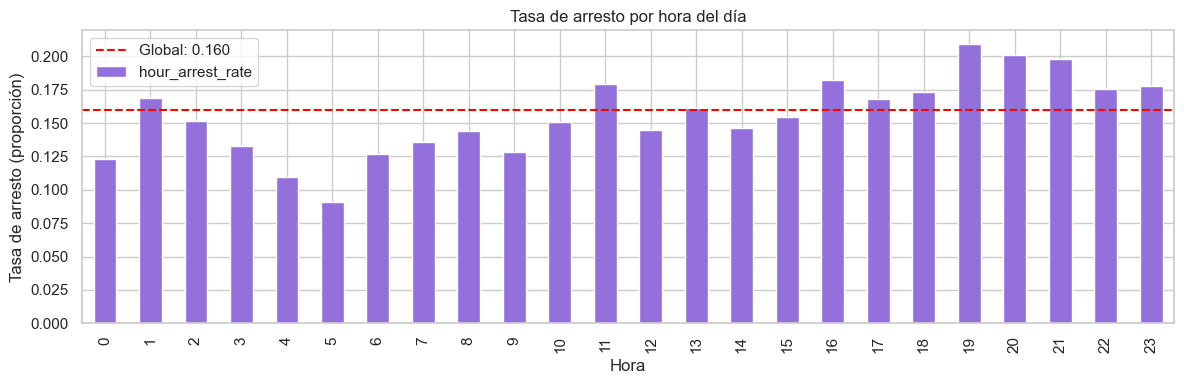

In [11]:
hour_stats = (
    X_train[['hour']]
    .assign(Arrest=y_train.values)
    .groupby('hour')['Arrest']
    .agg(['sum', 'count'])
    .rename(columns={'sum': 'arrestos', 'count': 'total'})
)
hour_stats['hour_arrest_rate'] = (hour_stats['arrestos'] + 1) / (hour_stats['total'] + 2)
hour_arrest_map = hour_stats['hour_arrest_rate'].to_dict()

X_train['hour_arrest_rate'] = X_train['hour'].map(hour_arrest_map).fillna(global_rate)
X_test['hour_arrest_rate']  = X_test['hour'].map(hour_arrest_map).fillna(global_rate)

fig, ax = plt.subplots(figsize=(12, 4))
hour_stats['hour_arrest_rate'].plot(kind='bar', ax=ax, color='mediumpurple', edgecolor='white')
ax.axhline(global_rate, color='red', linestyle='--', lw=1.5, label=f'Global: {global_rate:.3f}')
ax.set_title('Tasa de arresto por hora del día')
ax.set_xlabel('Hora')
ax.set_ylabel('Tasa de arresto (proporción)')
ax.set_xticks(range(24))
ax.legend()
plt.tight_layout()
plt.show()

### Feature: `domestic_location_match`

Indica si el lugar donde ocurrió el crimen es **consistente** con su clasificación como doméstico.
Un crimen marcado como `Domestic=True` debería ocurrir en una residencia o apartamento; si aparece
en la calle o en un bar, es un caso atípico que puede reflejar un error de carga o una dinámica
inusual del incidente.

La feature cruza `Domestic` con `Location Description` usando un conjunto de ubicaciones
residenciales esperables. Toma valor `1` cuando el crimen es doméstico **y** ocurre en un lugar
consistente, y `0` en cualquier otro caso.

En el conjunto de entrenamiento, el **14.5% del total** de crímenes cumple ambas condiciones.
Visto desde los crímenes domésticos solos, el **75.6% ocurre en lugar residencial** (match)
y el 24.4% restante ocurre en otro tipo de ubicación (mismatch). Ambos números son consistentes:
los crímenes domésticos representan ~19% del dataset, y `19% × 75% ≈ 14%`.

La hipótesis es que los casos con match están mejor documentados y tienen mayor probabilidad
de arresto, mientras que los domésticos en lugares inconsistentes pueden reflejar registros
incompletos o situaciones donde la víctima no colaboró con la identificación del lugar.



In [12]:
DOMESTIC_LOCATIONS = {
    'RESIDENCE', 'APARTMENT', 'RESIDENCE-GARAGE', 'RESIDENTIAL YARD (FRONT/BACK)',
    'HOUSE', 'DRIVEWAY - RESIDENTIAL', 'RESIDENCE PORCH/HALLWAY', 'CHA APARTMENT',
    'CHA HALLWAY/STAIRWELL/ELEVATOR', 'NURSING HOME/RETIREMENT HOME'
}

X_train['domestic_location_match'] = (
    (X_train['Domestic'] == 1) & (X_train['Location Description'].isin(DOMESTIC_LOCATIONS))
).astype(int)
X_test['domestic_location_match'] = (
    (X_test['Domestic'] == 1) & (X_test['Location Description'].isin(DOMESTIC_LOCATIONS))
).astype(int)

print(f"Train — domestic_location_match=1: {X_train['domestic_location_match'].sum():,} "
      f"({X_train['domestic_location_match'].mean()*100:.1f}% del total)")
print(f"Test  — domestic_location_match=1: {X_test['domestic_location_match'].sum():,} "
      f"({X_test['domestic_location_match'].mean()*100:.1f}% del total)")

Train — domestic_location_match=1: 27,326 (14.5% del total)
Test  — domestic_location_match=1: 6,730 (14.2% del total)


### Análisis de consistencia: crímenes domésticos × lugar

Antes de usar la feature en el modelo, se analiza qué tan bien captura el set de ubicaciones
residenciales definido manualmente los crímenes domésticos reales.

El **75.6%** de los crímenes domésticos ocurre en un lugar del set (match). El 24.4% restante
(mismatch) merece atención: puede tratarse de ubicaciones residenciales no contempladas en el set
(por ejemplo `CHA PARKING LOT` o variantes de `HALLWAY`) o de casos genuinamente atípicos
(peleas que empezaron adentro y terminaron en la calle, incidentes en casa de terceros, etc.).

El top 10 de lugares del mismatch permite decidir si conviene ampliar `DOMESTIC_LOCATIONS`
para mejorar la cobertura, o si esos casos son ruido real que la feature debe capturar como `0`.

Crímenes domésticos totales:               36,126
  → en lugar residencial (match):          27,326  (75.6%)
  → en otro lugar (mismatch):               8,800  (24.4%)

Top 10 lugares de crímenes domésticos fuera de ubicación residencial:
Location Description
STREET                                    4005
SIDEWALK                                  1156
VEHICLE NON-COMMERCIAL                     407
ALLEY                                      388
PARKING LOT / GARAGE (NON RESIDENTIAL)     355
OTHER (SPECIFY)                            270
RESIDENCE - PORCH / HALLWAY                254
RESIDENCE - YARD (FRONT / BACK)            252
HOTEL / MOTEL                              163
RESTAURANT                                 149


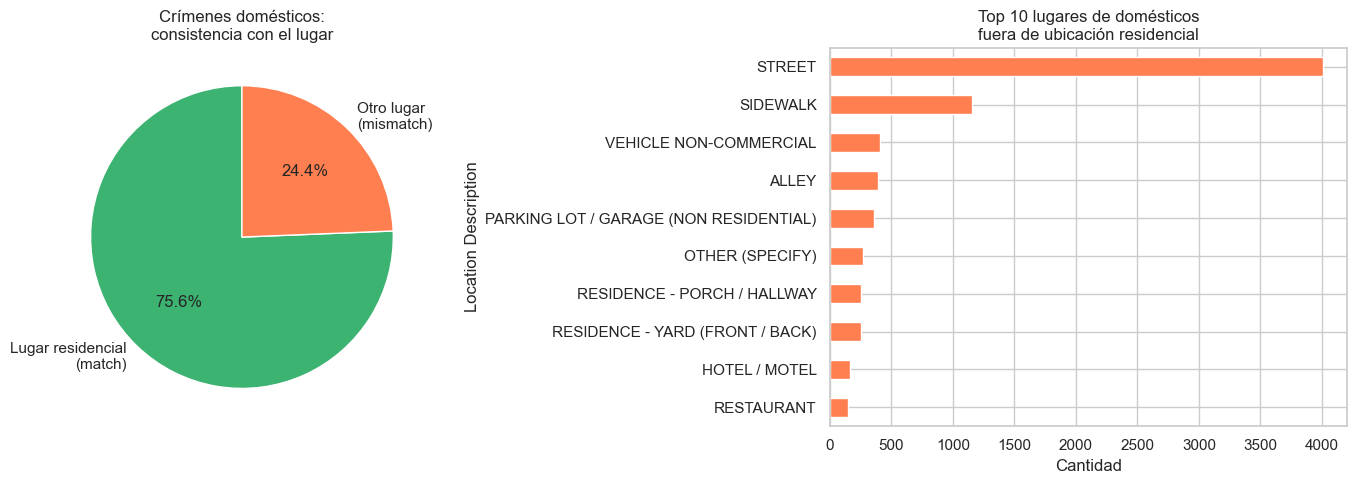

In [13]:
# Index Code ya fue normalizado a mayúsculas en la limpieza# Entre los crímenes marcados como Domestic=True,
# ¿qué porcentaje ocurre en un lugar residencial esperado?

tmp = X_train[['Domestic', 'Location Description']].copy()
tmp['is_residential'] = tmp['Location Description'].isin(DOMESTIC_LOCATIONS).astype(int)

total_domestic     = (tmp['Domestic'] == 1).sum()
domestic_residencial = ((tmp['Domestic'] == 1) & (tmp['is_residential'] == 1)).sum()
domestic_otro        = ((tmp['Domestic'] == 1) & (tmp['is_residential'] == 0)).sum()

print(f"Crímenes domésticos totales:              {total_domestic:>7,}")
print(f"  → en lugar residencial (match):         {domestic_residencial:>7,}  ({domestic_residencial/total_domestic*100:.1f}%)")
print(f"  → en otro lugar (mismatch):             {domestic_otro:>7,}  ({domestic_otro/total_domestic*100:.1f}%)")

# Top 10 lugares donde ocurren los domésticos que NO son residenciales
top_mismatch = (
    tmp[(tmp['Domestic'] == 1) & (tmp['is_residential'] == 0)]
    ['Location Description'].value_counts().head(10)
)
print(f"\nTop 10 lugares de crímenes domésticos fuera de ubicación residencial:")
print(top_mismatch.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie: match vs mismatch dentro de los domésticos
axes[0].pie(
    [domestic_residencial, domestic_otro],
    labels=['Lugar residencial\n(match)', 'Otro lugar\n(mismatch)'],
    autopct='%1.1f%%',
    colors=['mediumseagreen', 'coral'],
    startangle=90
)
axes[0].set_title('Crímenes domésticos:\nconsistencia con el lugar')

# Barh: top lugares del mismatch
top_mismatch.sort_values().plot(kind='barh', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Top 10 lugares de domésticos\nfuera de ubicación residencial')
axes[1].set_xlabel('Cantidad')

plt.tight_layout()
plt.show()

### Feature: `month_crime_zscore`

Mide qué tan **anómalo** es el volumen de crímenes del día en que ocurrió el incidente,
relativizado por el comportamiento típico de ese mes.

Se calcula como el z-score del conteo diario de crímenes dentro de cada mes:
un valor positivo alto indica un día de pico inusual de actividad criminal,
un valor negativo indica un día tranquilo.

La hipótesis es que en días de alta actividad la policía opera con recursos más dispersos,
lo que puede reducir la tasa de arrestos. Esta variable complementa los features temporales
existentes (`hour`, `is_night`, `month`): mientras esos capturan *cuándo* ocurre el crimen,
`month_crime_zscore` captura el **contexto operativo** del día.

Los estadísticos de media y desvío por mes se aprenden exclusivamente sobre el conjunto
de entrenamiento y se aplican al test sin reajuste.

month_crime_zscore — train | min: -2.66 | max: 3.52 | media: -0.00


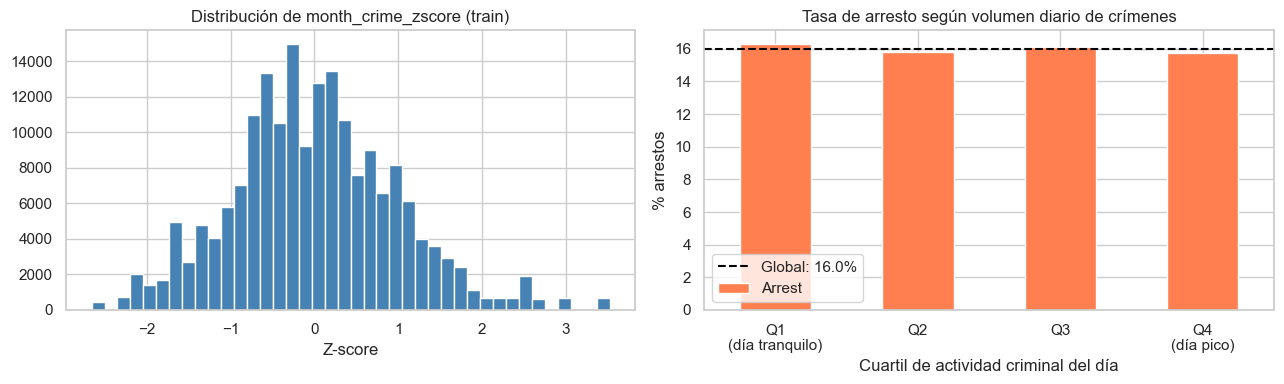

In [14]:
# Calcular volumen diario y zscore por mes — aprendido en TRAIN
X_train['date_only'] = X_train['Date'].dt.date
daily_vol = X_train.groupby('date_only').size().rename('daily_count')
X_train = X_train.join(daily_vol, on='date_only')

monthly_stats = (
    X_train.groupby('month')['daily_count']
    .agg(['mean', 'std'])
    .rename(columns={'mean': 'month_mean', 'std': 'month_std'})
)

X_train = X_train.join(monthly_stats, on='month')
X_train['month_crime_zscore'] = (
    (X_train['daily_count'] - X_train['month_mean']) / X_train['month_std'].replace(0, 1)
)
X_train = X_train.drop(columns=['date_only', 'daily_count', 'month_mean', 'month_std'])

# Aplicar al test usando estadísticos del TRAIN
X_test['date_only'] = X_test['Date'].dt.date
daily_vol_test = X_test.groupby('date_only').size().rename('daily_count')
X_test = X_test.join(daily_vol_test, on='date_only')
X_test = X_test.join(monthly_stats, on='month')
X_test['month_crime_zscore'] = (
    (X_test['daily_count'] - X_test['month_mean']) / X_test['month_std'].replace(0, 1)
)
X_test = X_test.drop(columns=['date_only', 'daily_count', 'month_mean', 'month_std'])

print(f"month_crime_zscore — train | min: {X_train['month_crime_zscore'].min():.2f} | "
      f"max: {X_train['month_crime_zscore'].max():.2f} | "
      f"media: {X_train['month_crime_zscore'].mean():.2f}")

# Tasa de arresto por cuartil de zscore
tmp = X_train[['month_crime_zscore']].assign(Arrest=y_train.values)
tmp['zscore_bin'] = pd.qcut(tmp['month_crime_zscore'], q=4, labels=['Q1\n(día tranquilo)', 'Q2', 'Q3', 'Q4\n(día pico)'])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
tmp['month_crime_zscore'].hist(bins=40, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Distribución de month_crime_zscore (train)')
axes[0].set_xlabel('Z-score')

arrest_by_bin = tmp.groupby('zscore_bin', observed=True)['Arrest'].mean() * 100
arrest_by_bin.plot(kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].axhline(y_train.mean() * 100, color='black', linestyle='--', lw=1.5, label=f'Global: {y_train.mean()*100:.1f}%')
axes[1].set_title('Tasa de arresto según volumen diario de crímenes')
axes[1].set_xlabel('Cuartil de actividad criminal del día')
axes[1].set_ylabel('% arrestos')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend()
plt.tight_layout()
plt.show()